In [1]:
import numpy as np
import pandas as pd

In [2]:
df_raw = pd.read_csv('property_listings.csv')

In [3]:
#Converts the columns to the best possible data types
#Permet de reconnaître les colonnes string, integer ou encore booléennes etc...
df_raw = df_raw.convert_dtypes()

In [4]:
#Prints the 5 first and last rows
df_raw

,zpid,price,homeStatus,homeType,datePosted,streetAddress,city,state,zipcode,county,...,rentZestimate,bathrooms,bedrooms,pageViewCount,favoriteCount,propertyTaxRate,timeOnZillow,dateSold,url,lastUpdated
0,32107262,750000,Recently Sold,Multi Family,2024-03-19,7417 87th Rd,Jamaica,NY,11421,Queens County,...,2930,2.0,<NA>,20,0,0.86,9 hours,2024-11-24,https://www.zillow.com/homedetails/7417-87th-R...,2024-11-25 09:04:11.007468 UTC
1,20503342,3995,Recently Sold,Apartment,2024-09-24,1300 Midvale Ave APT 510,Los Angeles,CA,90024,Los Angeles County,...,3867,2.0,2,187,5,1.16,9 hours,2024-11-24,https://www.zillow.com/homedetails/1300-Midval...,2024-11-25 09:04:11.007468 UTC
2,20183958,820000,Recently Sold,Single Family,2024-10-27,8300 Capps Ave,Northridge,CA,91324,Los Angeles County,...,4540,2.0,3,21,0,1.16,9 hours,2024-11-24,https://www.zillow.com/homedetails/8300-Capps-...,2024-11-25 09:04:11.007468 UTC
3,32332472,550000,Recently Sold,Single Family,2024-07-09,433 Hamden Ave,Staten Island,NY,10306,Richmond County,...,2668,1.0,2,96,0,0.89,9 hours,2024-11-24,https://www.zillow.com/homedetails/433-Hamden-...,2024-11-25 09:04:11.007468 UTC
4,352427429,703478,Recently Sold,Single Family,2024-06-19,504 Edwin St #8,Nashville,TN,37207,Davidson County,...,3599,4.0,4,7,0,0.57,9 hours,2024-11-24,https://www.zillow.com/homedetails/504-Edwin-S...,2024-11-25 09:04:11.007468 UTC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18773,16735997,994000,For Sale,Condo,2024-11-24,17616 Corte Potosi,San Diego,CA,92128,San Diego County,...,3056,2.0,2,45,1,1.17,5 hours,<NA>,https://www.zillow.com/homedetails/17616-Corte...,2024-11-25 05:33:30.941175 UTC
18774,16823913,1390000,For Sale,Single Family,2024-11-24,10941 Waterton Rd,San Diego,CA,92131,San Diego County,...,5248,4.0,5,440,35,1.17,7 hours,<NA>,https://www.zillow.com/homedetails/10941-Water...,2024-11-25 05:33:30.941175 UTC
18775,17176040,795000,For Sale,Single Family,2024-11-24,3954 Via Del Bardo,San Ysidro,CA,92173,San Diego County,...,3744,3.0,4,35,2,1.17,21 hours,<NA>,https://www.zillow.com/homedetails/3954-Via-De...,2024-11-25 05:33:30.941175 UTC
18776,15177502,950000,For Sale,Single Family,2024-11-24,22 Chicago Way,San Francisco,CA,94112,San Francisco County,...,3578,2.0,2,596,33,1.18,1 day,<NA>,https://www.zillow.com/homedetails/22-Chicago-...,2024-11-25 05:33:30.941175 UTC


In [5]:
df_raw.shape

(18778, 23)

In [6]:
#Names of the different columns
df_raw.columns

Index(['zpid', 'price', 'homeStatus', 'homeType', 'datePosted',
       'streetAddress', 'city', 'state', 'zipcode', 'county', 'yearBuilt',
       'livingArea', 'livingAreaUnits', 'rentZestimate', 'bathrooms',
       'bedrooms', 'pageViewCount', 'favoriteCount', 'propertyTaxRate',
       'timeOnZillow', 'dateSold', 'url', 'lastUpdated'],
      dtype='object')

In [7]:
len(df_raw.columns)

23

In [8]:
#Displays the components of the 5 first rows, with the columns and the rows transposed
def display_all(df):
    with pd.option_context("display.max_rows", 1000, "display.max_columns", 1000): 
        display(df)

display_all(df_raw.head().T)

,0,1,2,3,4
zpid,32107262,20503342,20183958,32332472,352427429
price,750000,3995,820000,550000,703478
homeStatus,Recently Sold,Recently Sold,Recently Sold,Recently Sold,Recently Sold
homeType,Multi Family,Apartment,Single Family,Single Family,Single Family
datePosted,2024-03-19,2024-09-24,2024-10-27,2024-07-09,2024-06-19
streetAddress,7417 87th Rd,1300 Midvale Ave APT 510,8300 Capps Ave,433 Hamden Ave,504 Edwin St #8
city,Jamaica,Los Angeles,Northridge,Staten Island,Nashville
state,NY,CA,CA,NY,TN
zipcode,11421,90024,91324,10306,37207
county,Queens County,Los Angeles County,Los Angeles County,Richmond County,Davidson County


In [9]:
display_all(df_raw.describe(include = 'all').T)

#Output includes (for numeric columns):
#count: Number of non-null values
#mean: Average value
#std: Standard deviation (spread of data)
#min: Minimum value
#25%: First quartile (25th percentile)
#50%: Median (50th percentile)
#75%: Third quartile (75th percentile)
#max: Maximum value

#For Non-Numeric Columns (categorical, string, boolean):
#count: Number of non-null values
#unique: Number of unique categories
#top: Most frequent value
#freq: Frequency of the most frequent value

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
zpid,18777.0,<NA>,<NA>,<NA>,263198307.893487,527739916.99909,1069739.0,26247162.0,52963188.0,321901220.0,2146973966.0
price,18777.0,<NA>,<NA>,<NA>,673023.765298,3630882.428257,0.0,252500.0,399999.0,690000.0,475000000.0
homeStatus,18777,7,For Sale,15003,NaN,NaN,NaN,NaN,NaN,NaN,NaN
homeType,18777,7,Single Family,11304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
datePosted,18750,344,2024-11-22,2531,NaN,NaN,NaN,NaN,NaN,NaN,NaN
streetAddress,18777,18379,(Undisclosed Address),39,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,18777,323,Houston,1269,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,18777,21,TX,3288,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zipcode,18777.0,<NA>,<NA>,<NA>,51667.758428,28080.881461,2108.0,30047.0,44135.0,78249.0,98199.0
county,18763,67,Harris County,1323,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Frequency table of the variable: city (categorical)

In [10]:
x = np.array(df_raw['city'].dropna()[:])
x

array(['Jamaica', 'Los Angeles', 'Northridge', ..., 'San Ysidro',
       'San Francisco', 'Seattle'], dtype=object)

In [11]:
levels, ni = np.unique(x, return_counts=True)
levels, ni, sum(ni)

(array(['Acworth', 'Allston', 'Alpharetta', 'Amherst', 'Anchorage',
        'Anderson Township', 'Antioch', 'Arvada', 'Arverne', 'Astoria',
        'Athens', 'Atlanta', 'Atlantic Beach', 'Austell', 'Austin',
        'Avondale Estates', 'Ball Ground', 'Baltimore', 'Bayside',
        'Bellerose', 'Beverly Hills', 'Blasdell', 'Boerne', 'Boston',
        'Brentwood', 'Briarwood', 'Brighton', 'Broadview', 'Bronx',
        'Brookhaven', 'Brooklyn', 'Brooks', 'Brownsburg', 'Buda',
        'Buffalo', 'Buford', 'Burbank', 'Cambria Heights', 'Camby',
        'Canal Winchester', 'Canoga Park', 'Canton', 'Cave Creek',
        'Chamblee', 'Charleston', 'Charlestown', 'Charlotte', 'Chatsworth',
        'Cheektowaga', 'Chicago', 'Cincinnati', 'Clarkston', 'Clermont',
        'Cleveland', 'Cobb', 'College Park', 'College Point', 'College Pt',
        'Columbus', 'Converse', 'Conyers', 'Corona', 'Cumming',
        'Curtis Bay', 'Cypress', 'Dacula', 'Dallas', 'Daniel Island',
        'Dawsonville', 'Dec

In [12]:
n=len(df_raw)
fi = ni/n
fi, sum(fi)

(array([5.32538076e-05, 5.32538076e-05, 1.86388327e-03, 6.39045692e-04,
        1.06507615e-04, 5.32538076e-05, 3.88752796e-03, 5.32538076e-05,
        1.06507615e-04, 7.98807115e-04, 1.06507615e-04, 2.31654063e-02,
        1.06507615e-04, 1.01182235e-03, 1.84790713e-02, 1.59761423e-04,
        1.06507615e-04, 2.67866652e-02, 5.85791884e-04, 5.32538076e-05,
        2.66269038e-04, 5.32538076e-05, 1.06507615e-04, 3.46149750e-03,
        7.45553307e-04, 5.32538076e-05, 8.52060922e-04, 5.32538076e-05,
        6.17744169e-03, 5.32538076e-05, 1.85855789e-02, 5.32538076e-05,
        5.32538076e-05, 7.98807115e-04, 7.40227926e-03, 1.43785281e-03,
        1.06507615e-04, 1.06507615e-04, 3.72776654e-04, 6.92299499e-04,
        1.11832996e-03, 2.34316754e-03, 5.85791884e-04, 2.13015231e-04,
        5.00585792e-03, 5.32538076e-05, 3.00884013e-02, 7.45553307e-04,
        1.11832996e-03, 5.54904676e-02, 1.23548834e-02, 5.32538076e-05,
        5.32538076e-05, 1.04910001e-02, 5.32538076e-05, 1.065076

In [13]:
ft_city = pd.DataFrame(data = np.transpose([ni, fi]), index = levels, columns = ['frequencies', 'relative frequencies'])
ft_city

,frequencies,relative frequencies
Acworth,1.0,0.000053
Allston,1.0,0.000053
Alpharetta,35.0,0.001864
Amherst,12.0,0.000639
Anchorage,2.0,0.000107
...,...,...
Winnetka,12.0,0.000639
Woodhaven,1.0,0.000053
Woodland Hills,26.0,0.001385
Woodside,9.0,0.000479


Graphics for the variable: city (bar charts and pie charts)

In [14]:
import scipy.stats as st
import matplotlib.pyplot as plt

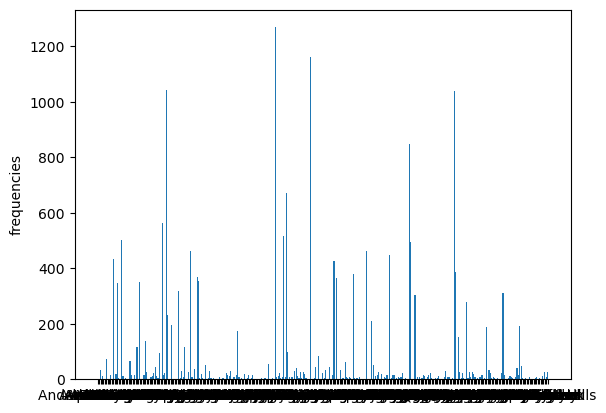

In [15]:
plt.bar(levels, ni)
plt.ylabel('frequencies')
plt.show()

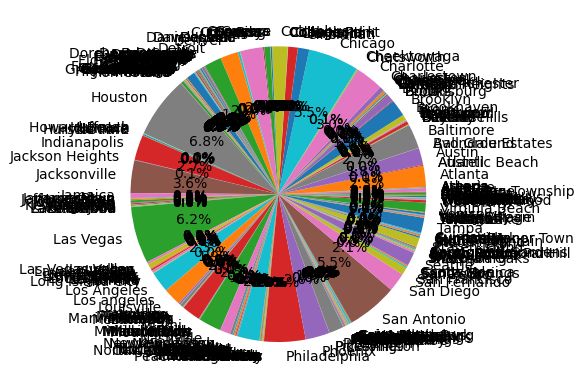

In [16]:
plt.pie(ni, labels = levels, autopct='%1.1f%%')
plt.show()

In [17]:
mode_value = df_raw['city'].mode()[0]
mode_value

'Houston'

For the variable "city", the most frequent value, or also called the mode, is "Houston". That means that there are more houses to buy in this area than in others.

Frequency table of the variable: state (categorical)

In [18]:
x1 = np.array(df_raw['state'].dropna()[:])
x1

array(['NY', 'CA', 'CA', ..., 'CA', 'CA', 'WA'], dtype=object)

In [19]:
levels1, ni1 = np.unique(x1, return_counts = True) 
levels1, ni1, sum(ni1)

(array(['AZ', 'CA', 'CO', 'FL', 'GA', 'IL', 'IN', 'KY', 'MA', 'MD', 'MI',
        'NC', 'NV', 'NY', 'OH', 'PA', 'SC', 'TN', 'TX', 'VA', 'WA'],
       dtype=object),
 array([ 566, 1499,  371, 1820, 1606, 1043,  523,  424,  166,  506,  362,
         569, 1214, 1561,  802, 1162,  148,  675, 3288,  192,  280]),
 np.int64(18777))

In [20]:
fi1 = ni1/n
fi1, sum(fi1)

(array([0.03014166, 0.07982746, 0.01975716, 0.09692193, 0.08552562,
        0.05554372, 0.02785174, 0.02257961, 0.00884013, 0.02694643,
        0.01927788, 0.03030142, 0.06465012, 0.08312919, 0.04270955,
        0.06188092, 0.00788156, 0.03594632, 0.17509852, 0.01022473,
        0.01491107]),
 np.float64(0.9999467461923527))

In [21]:
ft_state = pd.DataFrame(data = np.transpose([ni1, fi1]), index = levels1, columns = ['frequencies', 'relative frequencies'])
ft_state

,frequencies,relative frequencies
AZ,566.0,0.030142
CA,1499.0,0.079827
CO,371.0,0.019757
FL,1820.0,0.096922
GA,1606.0,0.085526
IL,1043.0,0.055544
IN,523.0,0.027852
KY,424.0,0.022580
MA,166.0,0.008840
MD,506.0,0.026946


Graphs for the variable: state (bar charts and pie charts)

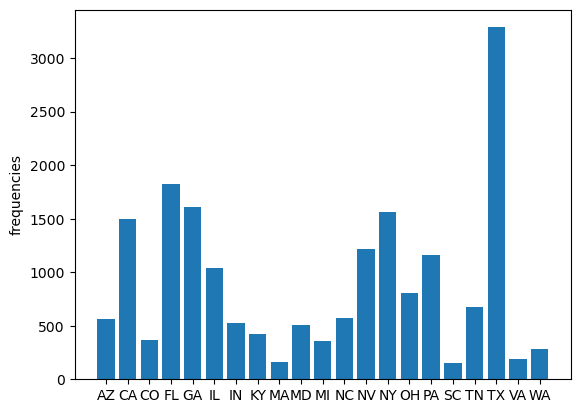

In [22]:
plt.bar(levels1, ni1)
plt.ylabel('frequencies')
plt.show()

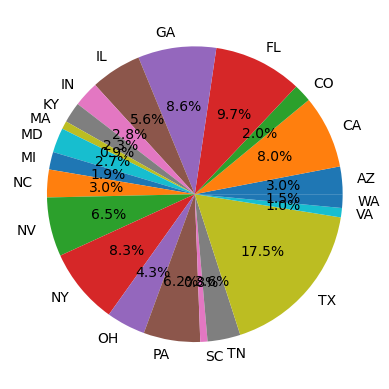

In [23]:
plt.pie(ni1, labels = levels1, autopct='%1.1f%%')
plt.show()

In [24]:
mode_state = df_raw['state'].mode()[0]
mode_state

'TX'

For the variable "state", the most frequent value, or also called the mode, is "Texas". That means that there are more houses to buy in this state than in others.

Frequency table of the variable: price (numerical continuous)

In [25]:
x2 = np.array(df_raw['price'].dropna()[:])
x2

array([750000,   3995, 820000, ..., 795000, 950000, 615000])

In [26]:
min(x2), max(x2)

(np.int64(0), np.int64(475000000))

In [27]:
bins = np.linspace(0, 500000000, 21)
bins, len (bins)

(array([0.00e+00, 2.50e+07, 5.00e+07, 7.50e+07, 1.00e+08, 1.25e+08,
        1.50e+08, 1.75e+08, 2.00e+08, 2.25e+08, 2.50e+08, 2.75e+08,
        3.00e+08, 3.25e+08, 3.50e+08, 3.75e+08, 4.00e+08, 4.25e+08,
        4.50e+08, 4.75e+08, 5.00e+08]),
 21)

In [28]:
ni2 = np.histogram(x2, bins = bins)[0]  
ni2

array([18772,     4,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     1])

In [29]:
lo = bins[:-1]
hi = bins[1:]
fi2 = ni2/n
Fi2 = np.cumsum(fi2)

In [30]:
ft_price = pd.DataFrame(data = np.transpose([lo, hi, ni2, fi2, Fi2]), columns = ['lo', 'hi', 'frequencies', 'relative frequencies', 'cummulative relative frequencies'])
ft_price

,lo,hi,frequencies,relative frequencies,cummulative relative frequencies
0,0.0,25000000.0,18772.0,0.999680,0.999680
1,25000000.0,50000000.0,4.0,0.000213,0.999893
2,50000000.0,75000000.0,0.0,0.000000,0.999893
3,75000000.0,100000000.0,0.0,0.000000,0.999893
4,100000000.0,125000000.0,0.0,0.000000,0.999893
5,125000000.0,150000000.0,0.0,0.000000,0.999893
6,150000000.0,175000000.0,0.0,0.000000,0.999893
7,175000000.0,200000000.0,0.0,0.000000,0.999893
8,200000000.0,225000000.0,0.0,0.000000,0.999893
9,225000000.0,250000000.0,0.0,0.000000,0.999893


Graphs for the variable: price

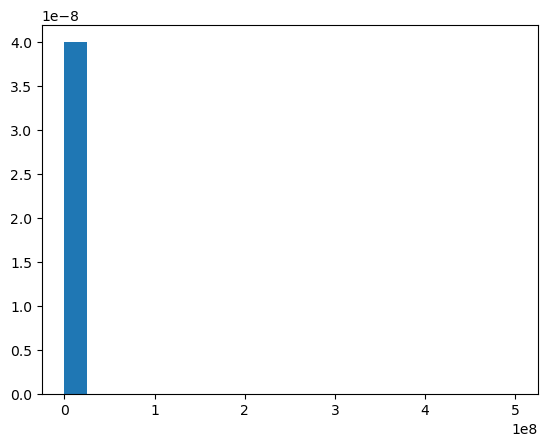

In [31]:
plt.hist(x2, bins, density = True)
plt.show()

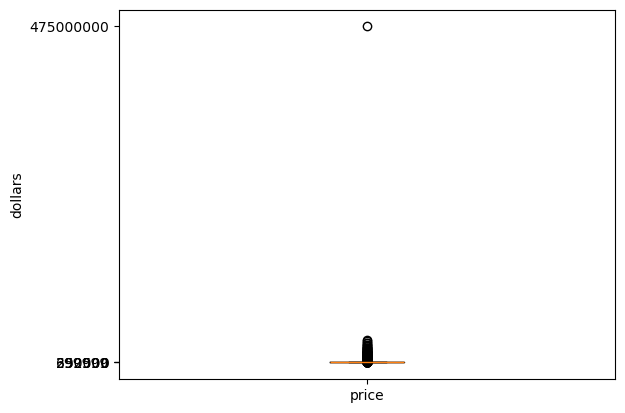

In [32]:
alpha = [0, 0.25, 0.5, 0.75, 1]
q = np.quantile(x2, alpha, method = 'inverted_cdf')
plt.boxplot(x2)
plt.yticks(q,q)
plt.ylabel('dollars')
plt.xticks([1], ['price'])
plt.show()

In [33]:
print(f'mean = {np.mean(x2):.2f}, standard deviation = {np.std(x2):.2f}, skewness = {st.skew(x2):.2f}, kurtosis = {st.kurtosis(x2):.2f}')

mean = 673023.77, standard deviation = 3630785.74, skewness = 119.06, kurtosis = 15511.37
